# Problem Statement

A US-based housing company named Surprise Housing has decided to enter the Australian market. The company uses data analytics to purchase houses at a price below their actual values and flip them on at a higher price. For the same purpose, the company has collected a data set from the sale of houses in Australia.

The company is looking at prospective properties to buy to enter the market. You are required to build a regression model using regularisation in order to predict the actual value of the prospective properties and decide whether to invest in them or not.

The company wants to know:
    
    - Which variables are significant in predicting the price of a house, and
    - How well those variables describe the price of a house.

Also, determine the optimal value of lambda for ridge and lasso regression.

Business Goal
  
  - model the price of houses with the available independent variables. This model will then be used by the management to understand how exactly the prices vary with the variables. They can accordingly manipulate the strategy of the firm and concentrate on areas that will yield high returns. Further, the model will be a good way for management to understand the pricing dynamics of a new market.


# Understand the Problem (Business → ML Mapping)

Solving 2 things at once:
  1. Machine Learning Objective
    
    - Predict house price (continuous variable) → Regression problem
    - Use regularization:
      - Ridge Regression
      - Lasso Regression
  
  2. Business Objective
  
    - Identify undervalued houses
    - Focus on key features that increase price
    - Avoid overpaying

# Step-By-Step Solution Approach
  
  1. Data Understanding
  2. Data Cleaning
  3. Exploratory Data Analysis (EDA)
  4. Features Engineering
  5. Model Buliding & Model Evaluation
  6. Features Importance
  7. Improve The Model

## 1. Data Understanding

In [1]:
# Pandas for data manipulation and analysis (DataFrames, CSV handling)
import pandas as pd

# Matplotlib for basic data visualization (plots, charts)
import matplotlib.pyplot as plt

# Seaborn for advanced statistical visualizations (heatmaps, distributions, pairplots)
import seaborn as sns

# Numpy for numerical computations and array operations
import numpy as np

# Normal distribution functions for statistical analysis (PDF, fitting distributions)
from scipy.stats import norm

# StandardScaler for feature scaling (important for ML models like Ridge/Lasso)
from sklearn.preprocessing import StandardScaler

# Statistical functions (e.g., skewness, kurtosis, hypothesis testing)
from scipy import stats

In [2]:
# Importing the warnings module to manage and control warning messages
import warnings

# Suppressing all warning messages to keep the output clean and readable
warnings.filterwarnings('ignore')

In [3]:
# Reading the dataset from a CSV file into a pandas DataFrame
house = pd.read_csv("/content/train.csv", na_values="NAN")

In [4]:
# Displaying the first 5 rows of the dataset to quickly inspect its structure and contents
house.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Displaying a concise summary of the dataset including:
# - Column names
# - Non-null (non-missing) value counts
# - Data types of each column
# Helps in understanding data structure and identifying missing values
print(house.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 2 Exploratory Data Analysis (EDA)

<Axes: xlabel='SalePrice', ylabel='Count'>

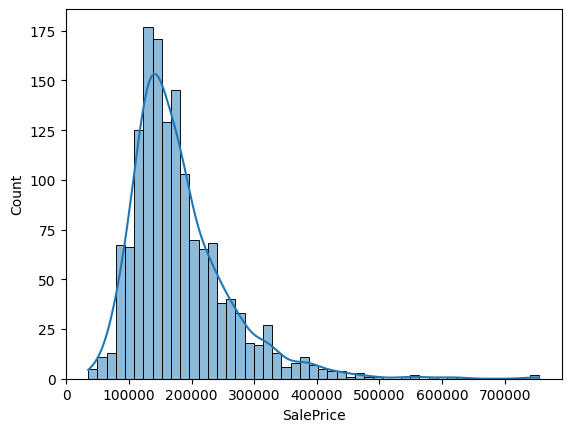

In [6]:
# Plotting the distribution of the target variable 'SalePrice' helps visualize the spread, skewness, and overall shape of house prices
sns.histplot(house['SalePrice'], kde=True)

## If they show this plot, say:

Target variable SalePrice exhibits a strong positive skew, indicating that most properties fall within a lower price range, while a small number of high-value properties create a long right tail. This non-normal distribution can negatively impact regression performance. Therefore, a log transformation is applied to normalize the data, improving model accuracy and stability.

In [7]:
# Applying log transformation to the target variable 'SalePrice' to reduce right skewness np.log1p(x) computes log(1 + x), which handles zero values
# safely this helps make the distribution more normal and improves regression model performance
house['SalePrice'] = np.log1p(house['SalePrice'])

In [8]:
# Calculating and printing the skewness of 'SalePrice'
# Skewness measures the asymmetry of the distribution value close to 0 indicates a symmetric (normal-like) distribution
print("Skewness: %f" % house['SalePrice'].skew())

# Calculating and printing the kurtosis of 'SalePrice'
# Kurtosis measures the "tailedness" or presence of outliers in the distribution higher values indicate more extreme outliers (heavy tails)
print("Kurtosis: %f" % house['SalePrice'].kurt())

Skewness: 0.121347
Kurtosis: 0.809519


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

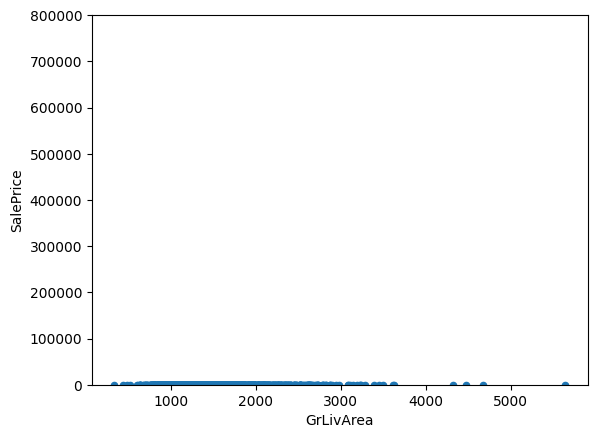

In [9]:
# Selecting the feature 'GrLivArea' (Above ground living area)
var = 'GrLivArea'

# Creating a new DataFrame combining 'SalePrice' and the selected variable this helps in analyzing the relationship between the feature and target variable
data = pd.concat([house['SalePrice'], house[var]], axis=1)

# Plotting a scatter plot to visualize the relationship between 'GrLivArea' and 'SalePrice'
# 1. x-axis: GrLivArea (independent variable)
# 2. y-axis: SalePrice (target variable)
# 3. ylim is set to limit the y-axis range for better visualization of most data points
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000))

In [10]:
# Removing extreme outliers based on 'GrLivArea' (living area) keeps only houses with living area less than 4000 sq ft this helps eliminate unusually large houses that may distort the model
house = house[house['GrLivArea'] < 4000]

In [11]:
# Selecting only numerical columns from the dataset outlier detection using Z-score works only on numeric data
num_cols = house.select_dtypes(include=[np.number]).columns

# Computing Z-scores for each value in numerical columns and Z-score indicates how many standard deviations a value is from the mean
z_scores = np.abs(stats.zscore(house[num_cols]))

# Defining the threshold for outlier detection common practice: values with Z-score > 3 are considered outliers
threshold = 3

# Filtering the dataset to keep only rows where ALL feature values are within the threshold rows with any feature exceeding the threshold are removed (treated as outliers)
house_z = house[(z_scores < threshold).all(axis=1)]

In [13]:
# Select only numerical columns for IQR calculation
numeric_house = house.select_dtypes(include=np.number)

# Calculating the first quartile (25th percentile) for each numerical column
Q1 = numeric_house.quantile(0.25)

# Calculating the third quartile (75th percentile) for each numerical column
Q3 = numeric_house.quantile(0.75)

# Computing the Interquartile Range (IQR) represents the spread of the middle 50% of the data
IQR = Q3 - Q1

# Filtering the dataset to remove outliers using the IQR method
# Create a boolean mask for numerical outliers
outlier_mask = ((numeric_house < (Q1 - 1.5 * IQR)) |
                (numeric_house > (Q3 + 1.5 * IQR))).any(axis=1)

# Apply the mask to the original 'house' DataFrame to remove rows containing numerical outliers
house_iqr = house[~outlier_mask]

In [16]:
# Creating a new binary feature 'is_large_house' based on 'GrLivArea'
# Assigns:
# 1 → if the house has a living area greater than 2800 sq ft (large house)
# 0 → otherwise (normal-sized house)
# this helps the model capture the impact of unusually large properties without removing them
house['is_large_house'] = (house['GrLivArea'] > 2800).astype(int)

<Axes: xlabel='GrLivArea'>

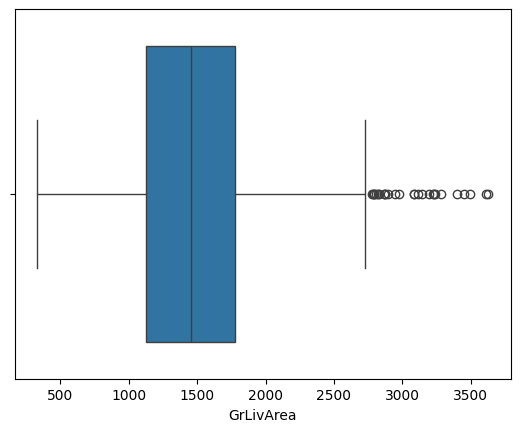

In [17]:
# Importing seaborn library for statistical data visualization
import seaborn as sns

# Creating a boxplot for the 'GrLivArea' feature (above-ground living area) helps visualize: median (central line), interquartile range (box), potential outliers (points outside whiskers)
sns.boxplot(x=house['GrLivArea'])

## If they show this plot, say:

boxplot of GrLivArea shows a right-skewed distribution with several high-value outliers beyond 2800 sq ft. These represent large houses that follow different pricing dynamics. Instead of removing them, a binary feature was created to capture their impact, improving model performance and interpretability

In [19]:
# Select only numerical columns for correlation calculation
numeric_house = house.select_dtypes(include=np.number)

# Computing the correlation of all numerical features with the target variable 'SalePrice'
# .corr() → calculates pairwise correlation between columns
# ['SalePrice'] → selects correlation values with respect to SalePrice only
# sort_values(ascending=False) → sorts features from highest to lowest correlation
corr = numeric_house.corr()['SalePrice'].sort_values(ascending=False)

# Displaying the top 10 features that have the strongest positive correlation with SalePrice these are the most important predictors for house price
print(corr.head(10))

SalePrice       1.000000
OverallQual     0.819240
GrLivArea       0.718844
GarageCars      0.680408
GarageArea      0.655212
TotalBsmtSF     0.641553
1stFlrSF        0.613742
FullBath        0.590919
YearBuilt       0.588977
YearRemodAdd    0.568986
Name: SalePrice, dtype: float64


<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

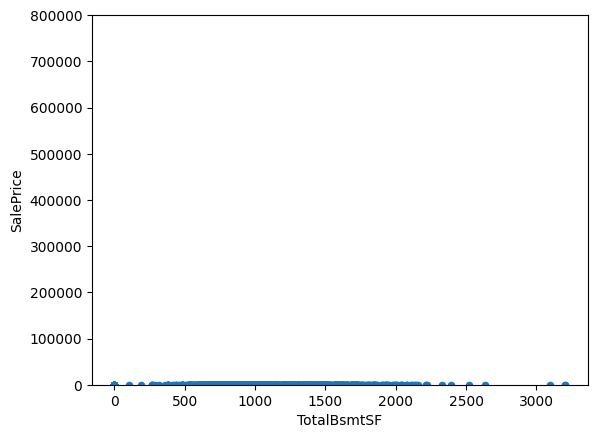

In [20]:
# Selecting the feature 'TotalBsmtSF' (total basement area in square feet)
var = 'TotalBsmtSF'

# Creating a new DataFrame combining the target variable 'SalePrice' and the selected feature 'TotalBsmtSF' for relationship analysis
data = pd.concat([house['SalePrice'], house[var]], axis=1)

# Plotting a scatter plot to visualize the relationship between basement area and house price
# 1. x-axis: Total basement area
# 2. y-axis: SalePrice
# 3. ylim is used to limit the y-axis range for better visualization of most data points
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000))

In [21]:
# Creating a new binary feature 'has_basement' based on 'TotalBsmtSF'
# Assigns:
# 1 → if the house has a basement (TotalBsmtSF > 0)
# 0 → if the house has no basement
# this helps capture the impact of basement presence as a separate factor in the model
house['has_basement'] = (house['TotalBsmtSF'] > 0).astype(int)

In [22]:
# Selecting only numerical columns from the dataset outlier detection using Z-score works only on numeric data
num_cols = house.select_dtypes(include=[np.number]).columns

# Computing Z-scores for each value in numerical columns and Z-score indicates how many standard deviations a value is from the mean
z_scores = np.abs(stats.zscore(house[num_cols]))

# Defining the threshold for outlier detection common practice: values with Z-score > 3 are considered outliers
threshold = 3

# Filtering the dataset to keep only rows where ALL feature values are within the threshold rows with any feature exceeding the threshold are removed (treated as outliers)
house_z = house[(z_scores < threshold).all(axis=1)]

In [23]:
# Select only numerical columns for IQR calculation
numeric_house = house.select_dtypes(include=np.number)

# Calculating the first quartile (25th percentile) for each numerical column
Q1 = numeric_house.quantile(0.25)

# Calculating the third quartile (75th percentile) for each numerical column
Q3 = numeric_house.quantile(0.75)

# Computing the Interquartile Range (IQR) represents the spread of the middle 50% of the data
IQR = Q3 - Q1

# Filtering the dataset to remove outliers using the IQR method
# Create a boolean mask for numerical outliers
outlier_mask = ((numeric_house < (Q1 - 1.5 * IQR)) |
                (numeric_house > (Q3 + 1.5 * IQR))).any(axis=1)

# Apply the mask to the original 'house' DataFrame to remove rows containing numerical outliers
house_iqr = house[~outlier_mask]

<Axes: xlabel='TotalBsmtSF'>

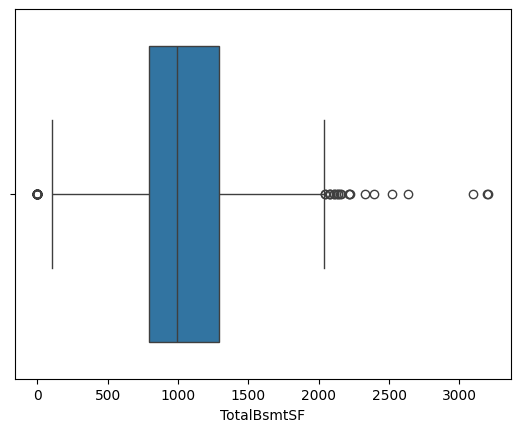

In [24]:
# Importing seaborn library for statistical data visualization
import seaborn as sns

# Creating a boxplot for the 'TotalBsmtSF' feature (above-ground living area) helps visualize: median (central line), interquartile range (box), potential outliers (points outside whiskers)
sns.boxplot(x=house['TotalBsmtSF'])

## If they show this plot, say:

Boxplot of TotalBsmtSF shows a right-skewed distribution with many zero values, indicating that a significant number of houses do not have basements. Additionally, several high-value outliers represent large basements. To handle this, a binary feature was created to capture basement presence, improving model performance.

(np.float64(-0.5), np.float64(9.5), np.float64(0.0), np.float64(800000.0))

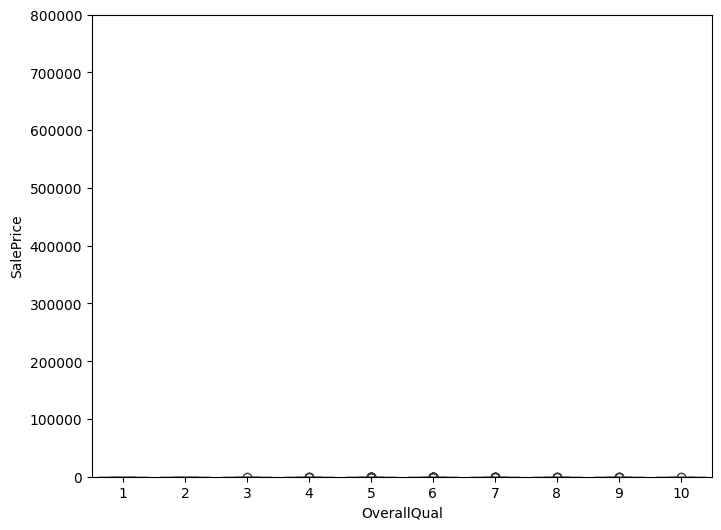

In [25]:
# Selecting the feature 'OverallQual' (overall material and finish quality of the house)
var = 'OverallQual'

# Creating a DataFrame combining 'SalePrice' (target) and 'OverallQual' (feature) this helps analyze how house prices vary across different quality levels
data = pd.concat([house['SalePrice'], house[var]], axis=1)

# Creating a figure and axis with specified size for better visualization
f, ax = plt.subplots(figsize=(8, 6))

# Plotting a boxplot to visualize the distribution of SalePrice across different quality levels
# 1. x-axis: OverallQual (categorical/ordinal feature)
# 2. y-axis: SalePrice (continuous target variable)
fig = sns.boxplot(x=var, y="SalePrice", data=data)

# Setting y-axis limits to focus on the main price range and improve readability
fig.axis(ymin=0, ymax=800000)

## If they show this plot, say:

Boxplot between OverallQual and SalePrice shows a strong positive relationship, where higher quality levels correspond to significantly higher prices. The trend appears non-linear, indicating that quality has a multiplicative effect on price. This makes OverallQual the most important predictor of house price.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111],
 [Text(0, 0, '1872'),
  Text(1, 0, '1875'),
  Text(2, 0, '1880'),
  Text(3, 0, '1882'),
  Text(4, 0, '1885'),
  Text(5, 0, '1890'),
  Text(6, 0, '1892'),
  Text(7, 0, '1893'),
  Text(8, 0, '1898'),
  Text(9, 0, '1900'),
  Text(10, 0, '1904'),
  Text(11, 0, '1905'),
  Text(12, 0, '1906'),
  Text(13, 0, '1908'),
  Text(14, 0,

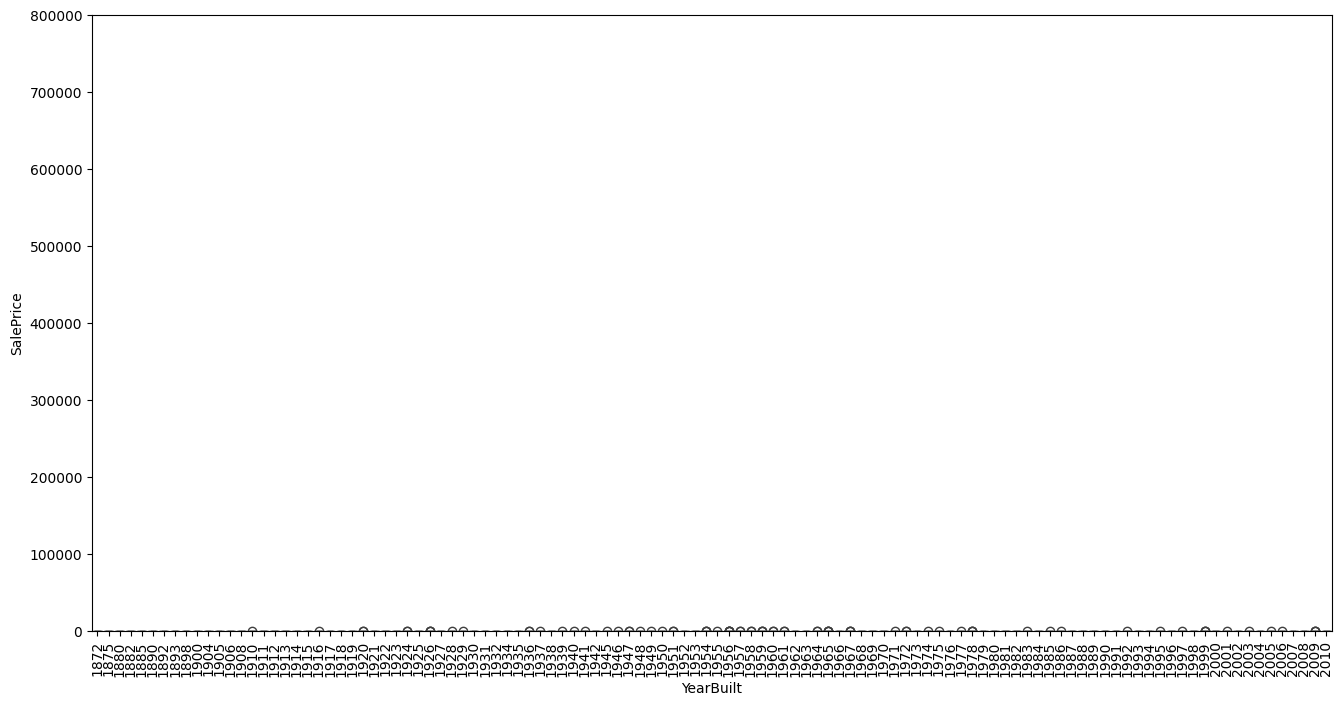

In [26]:
# Selecting the feature 'YearBuilt' (year in which the house was constructed)
var = 'YearBuilt'

# Creating a DataFrame combining 'SalePrice' (target variable) and 'YearBuilt' this helps analyze how house prices vary across construction years
data = pd.concat([house['SalePrice'], house[var]], axis=1)

# Creating a larger figure for better visualization since 'YearBuilt' has many categories
f, ax = plt.subplots(figsize=(16, 8))

# Plotting a boxplot to show distribution of SalePrice for each construction year
# 1. x-axis: YearBuilt (categorical/ordinal feature)
# 2. y-axis: SalePrice
fig = sns.boxplot(x=var, y="SalePrice", data=data)

# Setting y-axis limits to focus on the main price range
fig.axis(ymin=0, ymax=800000)

# Rotating x-axis labels by 90 degrees to avoid overlap and improve readability
plt.xticks(rotation=90)

## If they show this plot, say:

boxplot of YearBuilt shows that newer houses generally have higher prices, indicating a positive relationship between construction year and price. However, due to the high number of categories, the plot appears cluttered. To better capture this relationship, the feature was transformed into house age, which showed a clearer negative correlation with price.

In [27]:
# Creating a new feature 'Age' representing the age of the house at the time of sale calculated as: Year Sold - Year Built this converts 'YearBuilt' into a more meaningful and interpretable feature for modeling
house['Age'] = house['YrSold'] - house['YearBuilt']

# Displaying the 'has_basement' feature this binary feature indicates whether a house has a basement (1 = yes, 0 = no)
house['has_basement']

# Displaying the 'is_large_house' feature this binary feature indicates whether a house is large based on living area threshold (1 = large, 0 = normal)
house['is_large_house']

,is_large_house
0,0
1,0
2,0
3,0
4,0
...,...
1455,0
1456,0
1457,0
1458,0


<Axes: >

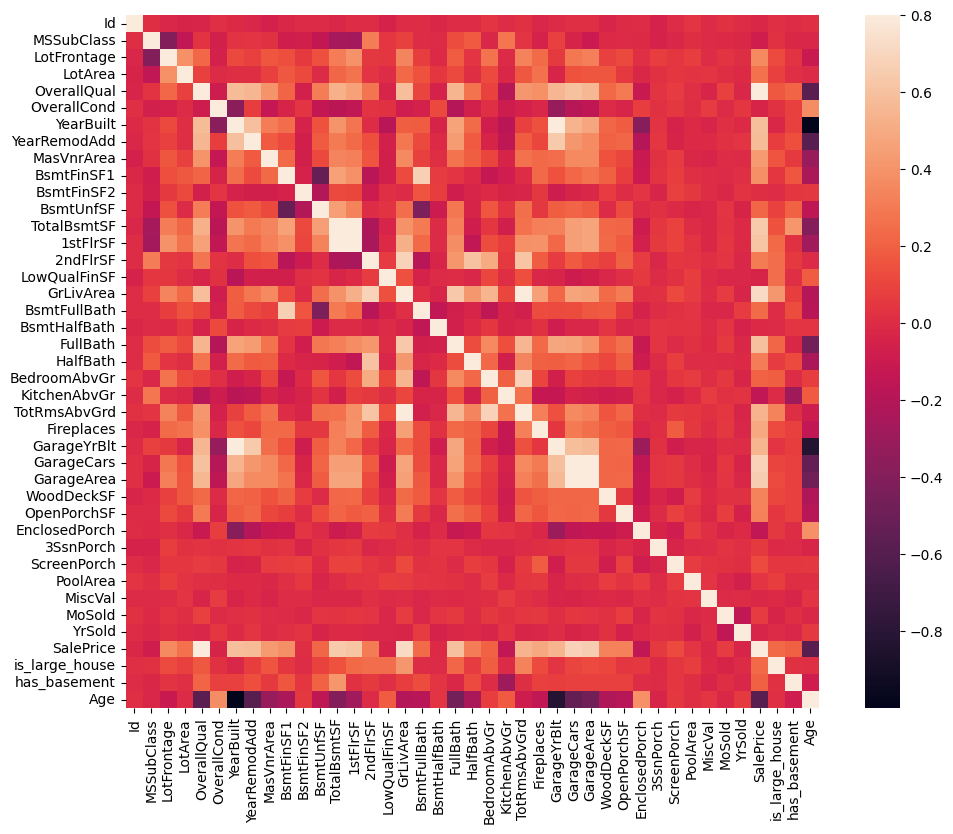

In [29]:
# Select only numerical columns from the dataset to compute correlation matrix
numeric_house = house.select_dtypes(include=np.number)

# Computing the correlation matrix for all numerical features in the dataset this shows pairwise relationships between variables (range: -1 to +1)
corrmat = numeric_house.corr()

# Creating a figure with a larger size for better visualization of the heatmap
f, ax = plt.subplots(figsize=(12, 9))

# Top correlated features with SalePrice
top_corr = numeric_house.corr()['SalePrice'].sort_values(ascending=False).head(10)

# Plotting the heatmap of the correlation matrix
# 1. vmax=0.8 → caps the color intensity at 0.8 to highlight strong correlations clearly
# 2. square=True → ensures each cell is square-shaped for better readability
sns.heatmap(corrmat, vmax=.8, square=True)

## If they show this plot, say:

Heatmap reveals that structural and quality-related features dominate price prediction, while strong inter-feature correlations highlight the need for regularization techniques like Ridge and Lasso to ensure model stability.

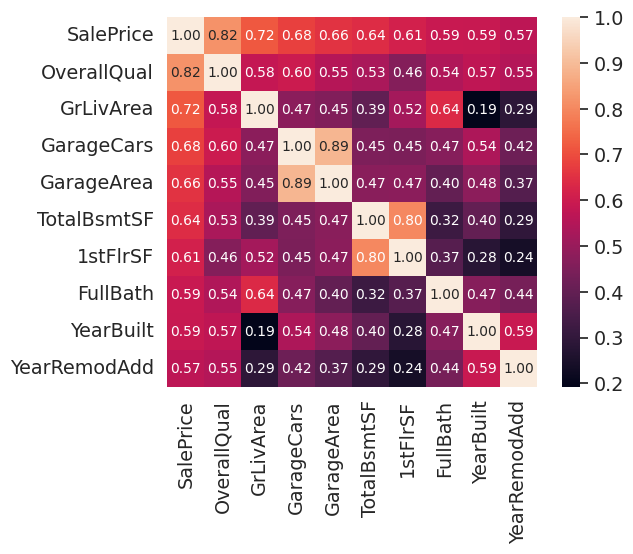

In [30]:
# Selecting top 'k' features that have the highest correlation with 'SalePrice'
k = 10
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index

# Computing correlation matrix only for these top features np.corrcoef() calculates pairwise correlation between selected variables
cm = np.corrcoef(house[cols].values.T)

# Setting font scale for better readability of annotations
sns.set(font_scale=1.25)

# Plotting heatmap of top correlated features
# 1. cbar=True → shows color bar (correlation scale)
# 2. annot=True → displays correlation values inside cells
# 3. square=True → makes cells square-shaped
# 4. fmt='.2f' → formats correlation values to 2 decimal places
# 5. annot_kws={'size': 10} → controls annotation text size
# 6. yticklabels & xticklabels → label axes with feature names
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)

# Displaying the heatmap
plt.show()

## If they show this plot, say:

Heatmap reveals strong multicollinearity among structural features, indicating overlapping information. Regularization techniques like Ridge and Lasso are essential to stabilize the model and perform feature selection

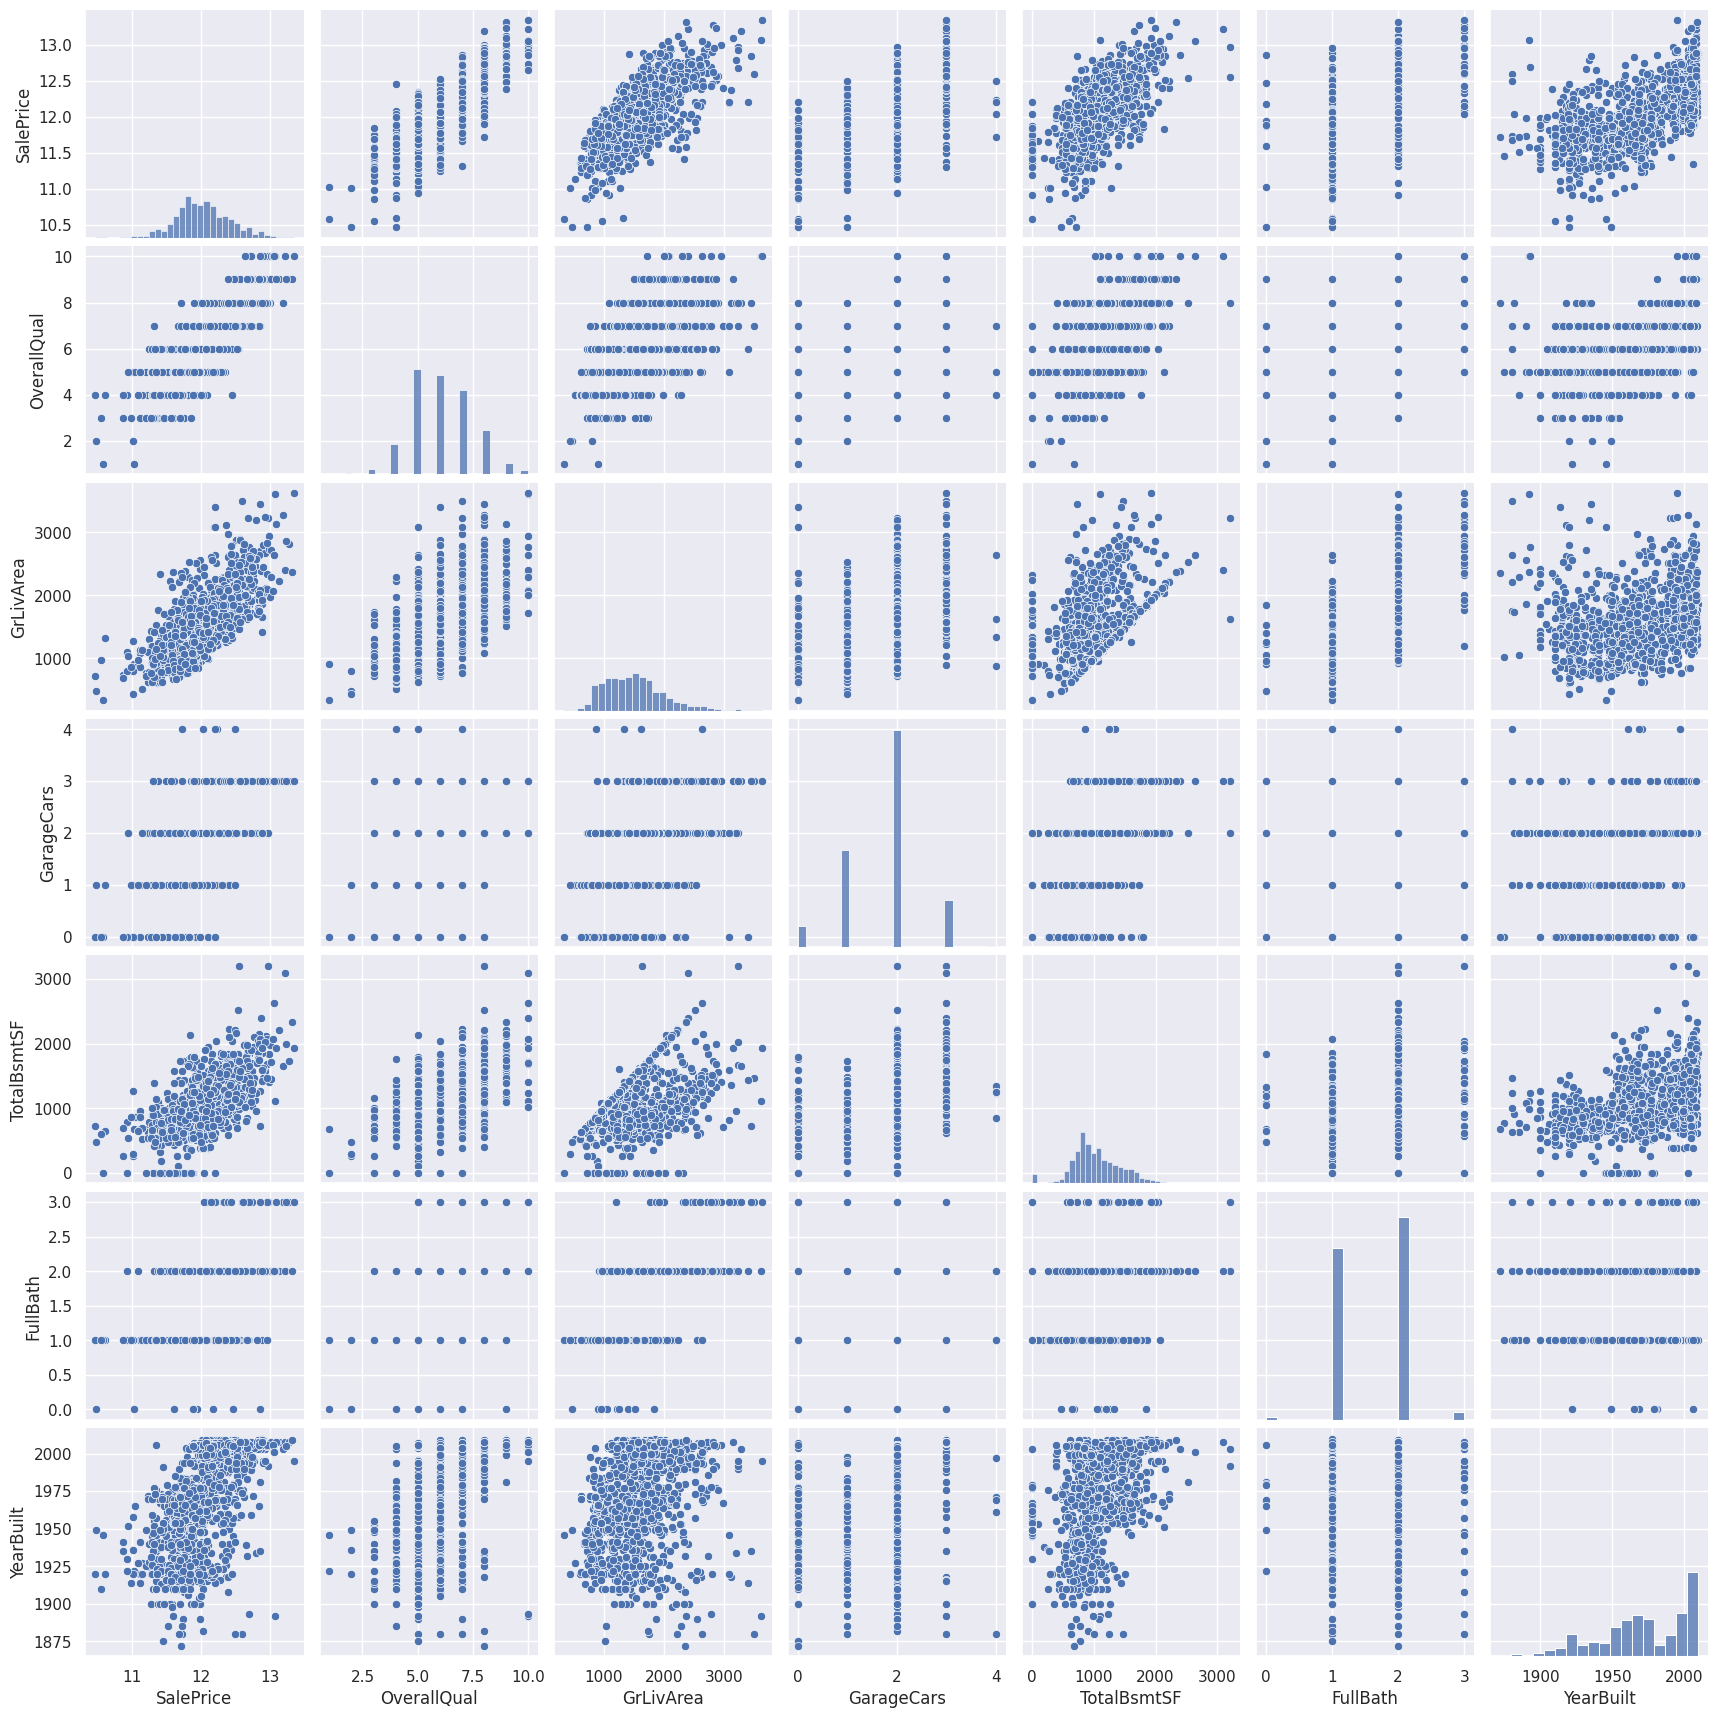

In [31]:
# Setting seaborn default style for better visualization aesthetics
sns.set()

# Selecting a subset of important features including the target variable 'SalePrice' these are top predictors identified from correlation analysis
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']

# Creating pairplot (scatterplot matrix) to visualize relationships between all selected features
sns.pairplot(house[cols], size=2.5)

# Displaying the plot
plt.show()

## If they show this plot, say:

Pairplot shows strong positive relationships between SalePrice and key features such as OverallQual, GrLivArea, and TotalBsmtSF. OverallQual exhibits a step-wise increase, indicating its dominant impact, while GrLivArea shows a strong linear relationship with price. Additionally, multicollinearity is observed among features like GrLivArea and TotalBsmtSF, which is addressed using regularization techniques

In [32]:
# Calculating the total number of missing values for each column
total = house.isnull().sum().sort_values(ascending=False)

# Calculating the percentage of missing values for each column missing count divided by total number of rows
percent = (house.isnull().sum() / house.isnull().count()).sort_values(ascending=False)

# Combining total and percentage of missing values into a single DataFrame
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

# Displaying top 20 columns with highest missing values
missing_data.head(20)

,Total,Percent
PoolQC,1451,0.996566
MiscFeature,1402,0.962912
Alley,1365,0.937500
Fence,1176,0.807692
MasVnrType,871,0.598214
FireplaceQu,690,0.473901
LotFrontage,259,0.177885
GarageYrBlt,81,0.055632
GarageQual,81,0.055632
GarageType,81,0.055632


In [33]:
# Creating a list of categorical features where missing values have semantic meaning
# In these columns, NaN does NOT indicate missing data but rather the absence of a feature
# Example:
# - 'Alley' → no alley access
# - 'BsmtQual', 'BsmtCond' → no basement
# - 'FireplaceQu' → no fireplace
# - 'GarageType', 'GarageQual' → no garage
# - 'PoolQC' → no pool
# - 'Fence' → no fence
# - 'MiscFeature' → no miscellaneous feature
# These columns should be handled by replacing NaN with a label like 'None' instead of imputing
null_has_meaning = ["Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish",
                    "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature"]

In [35]:
# Iterating through columns where missing values have semantic meaning (not true missing data)
for i in null_has_meaning:
    # Replacing NaN values with the string "None" this explicitly indicates absence of a feature (e.g., no basement, no garage, no pool)
    house[i].fillna("None", inplace=True)

In [36]:
# Importing SimpleImputer from sklearn to handle missing values
from sklearn.impute import SimpleImputer

# Initializing the imputer with
# 1. 'median' strategy missing values in numerical features will be replaced with the median of each column
# 2.  median is preferred for skewed data and is robust to outliers common in housing datasets
imputer = SimpleImputer(strategy="median")

In [37]:
# Calculating the total number of missing values for each column
total = house.isnull().sum().sort_values(ascending=False)

# Calculating the percentage of missing values for each column missing values divided by total number of rows in the dataset
percent = (house.isnull().sum() / house.isnull().count()).sort_values(ascending=False)

# Combining total and percentage of missing values into a single DataFrame
# 1. axis=1 → concatenate as columns
# 2. keys → assign column names 'Total' and 'Percent'
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

# Displaying top 6 columns with highest missing values helps prioritize which features need immediate handling
missing_data.head(6)

,Total,Percent
MasVnrType,871,0.598214
LotFrontage,259,0.177885
GarageYrBlt,81,0.055632
MasVnrArea,8,0.005495
Electrical,1,0.000687
Street,0,0.000000


In [38]:
# Dropping the column 'LotFrontage' from the dataset
# Reason: 'LotFrontage' likely contains a high percentage of missing values and may not provide reliable information after imputation,
house.drop("LotFrontage", axis=1, inplace=True)

In [39]:
# Calculating the total number of missing values (NaN) for each column
total = house.isnull().sum().sort_values(ascending=False)

# Calculating the percentage of missing values for each column missing values divided by total number of rows in the dataset
percent = (house.isnull().sum() / house.isnull().count()).sort_values(ascending=False)

# Combining total and percentage of missing values into a single DataFrame
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

# Displaying top columns with highest missing values helps prioritize which features need cleaning or removal
missing_data.head()

,Total,Percent
MasVnrType,871,0.598214
GarageYrBlt,81,0.055632
MasVnrArea,8,0.005495
Electrical,1,0.000687
Street,0,0.000000


In [40]:
# Filling missing values in 'GarageYrBlt' (year garage was built) using median imputation because the data is numerical and may contain outliers
# median provides a robust estimate without being affected by extreme values
house["GarageYrBlt"].fillna(house["GarageYrBlt"].median(), inplace=True)

# Filling missing values in 'MasVnrArea' (masonry veneer area in sq ft) again using median to handle skewness and outliers in numerical data
house["MasVnrArea"].fillna(house["MasVnrArea"].median(), inplace=True)

# Filling missing values in 'MasVnrType' (type of masonry veneer) using "None" to indicate absence of veneer rather than missing data this preserves the semantic meaning of the feature
house["MasVnrType"].fillna("None", inplace=True)

In [41]:
# Filling missing values in 'GarageYrBlt' (year the garage was built) using median imputation because the feature is numerical and may contain outliers
# median is robust and prevents distortion caused by extreme values assigning back to the column
house["GarageYrBlt"] = house["GarageYrBlt"].fillna(house["GarageYrBlt"].median())

In [42]:
# Calculating the total number of missing values (NaN) for each column
total = house.isnull().sum().sort_values(ascending=False)

# Calculating the percentage of missing values for each column missing values divided by total number of rows in the dataset
percent = (house.isnull().sum() / house.isnull().count()).sort_values(ascending=False)

# Combining total and percentage of missing values into a single DataFrame
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

# Displaying the top columns with the highest missing values helps prioritize which features require cleaning, imputation, or removal
missing_data.head()

,Total,Percent
Electrical,1,0.000687
MSSubClass,0,0.000000
Id,0,0.000000
LotArea,0,0.000000
Street,0,0.000000


In [43]:
# Removing all rows that contain any missing values (NaN) in the dataset this ensures that the dataset used for modeling is completely clean with no missing values that could affect model performance
house.dropna(inplace=True)

In [44]:
# Calculating the total number of missing values (NaN) in each column
total = house.isnull().sum().sort_values(ascending=False)

# Calculating the percentage of missing values for each column missing count divided by total number of rows
percent = (house.isnull().sum() / house.isnull().count()).sort_values(ascending=False)

# Combining total and percentage into a single DataFrame for better analysis
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

# Displaying top columns with highest missing values helps identify which features need further cleaning or can be dropped
missing_data.head()

,Total,Percent
Id,0,0.0
MSSubClass,0,0.0
MSZoning,0,0.0
LotArea,0,0.0
Street,0,0.0


In [45]:
# Displaying a concise summary of the dataset
# Includes:
# - column names
# - non-null value counts (to verify no missing data)
# - data types of each column (int, float, object, etc.)
# - memory usage
print(house.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1455 entries, 0 to 1459
Data columns (total 83 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              1455 non-null   int64  
 1   MSSubClass      1455 non-null   int64  
 2   MSZoning        1455 non-null   object 
 3   LotArea         1455 non-null   int64  
 4   Street          1455 non-null   object 
 5   Alley           1455 non-null   object 
 6   LotShape        1455 non-null   object 
 7   LandContour     1455 non-null   object 
 8   Utilities       1455 non-null   object 
 9   LotConfig       1455 non-null   object 
 10  LandSlope       1455 non-null   object 
 11  Neighborhood    1455 non-null   object 
 12  Condition1      1455 non-null   object 
 13  Condition2      1455 non-null   object 
 14  BldgType        1455 non-null   object 
 15  HouseStyle      1455 non-null   object 
 16  OverallQual     1455 non-null   int64  
 17  OverallCond     1455 non-null   int64 

In [46]:
# Getting the data type of each feature in the dataset helps identify whether a column is numerical or categorical
types_train = house.dtypes

# Selecting numerical features (int and float types) these features are used for mathematical operations and ML models
num_train = types_train[(types_train == 'int64') | (types_train == float)]

# Selecting categorical features (object type) these require encoding (e.g., one-hot encoding) before model training
cat_train = types_train[types_train == object]

In [47]:
# Converting the data types (types_train) into a DataFrame for easier manipulation
# 1. reset_index() → moves column names into a column
# 2. set_index(0) → sets data types as index
# 3. reset_index() → restructures DataFrame for counting
# 4. value_counts() counts how many features belong to each data type
pd.DataFrame(types_train).reset_index().set_index(0).reset_index()[0].value_counts()

,count
0,
object,43
int64,37
float64,3


In [48]:
# Extracting the names of numerical features from the dataset num_train.index contains column names of numerical variables
# Converting it into a list for easier use in preprocessing (e.g., scaling, imputation)
numerical_values_train = list(num_train.index)

In [49]:
# Printing the list of numerical feature names this helps verify which columns have been identified as numerical
# Useful for debugging and ensuring correct preprocessing (e.g., scaling, imputation)
print(numerical_values_train)

['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'is_large_house', 'has_basement', 'Age']


In [50]:
# Extracting the names of categorical features from the dataset
# 1. cat_train.index contains column names of categorical (object-type) variables
# Converting it into a list for easier use in encoding (e.g., one-hot encoding)
categorical_values_train = list(cat_train.index)

# Printing the list of categorical feature names helps verify correct identification before applying encoding techniques
print(categorical_values_train)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


<Axes: xlabel='SalePrice', ylabel='Count'>

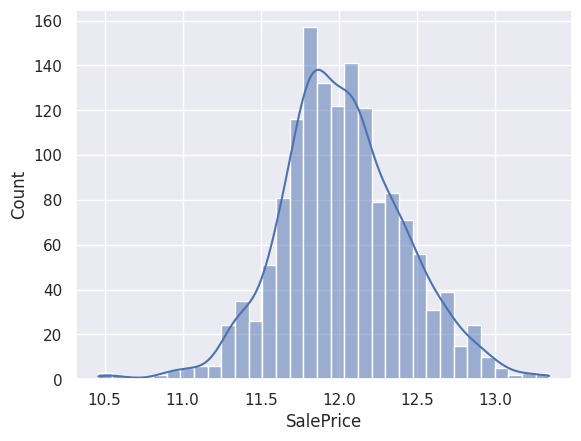

In [51]:
# Plotting the distribution of the target variable 'SalePrice'
# Helps visualize:
# - Shape of distribution (normal / skewed)
# - Presence of outliers
# - Overall spread of house prices
sns.histplot(house["SalePrice"], kde=True)

## If they show this plot, say:

After applying log transformation, the distribution of SalePrice becomes approximately normal, reducing skewness and the impact of outliers. This improves the performance and stability of regression models such as Ridge and Lasso

In [53]:
# Creating a new feature 'TransformedPrice' by applying natural logarithm to 'SalePrice' this transformation is used to reduce skewness and make the
# distribution more normal useful for improving the performance of regression models
house["TransformedPrice"] = np.log(house["SalePrice"])

In [54]:
# Printing the list of categorical feature names helps verify which columns are identified as categorical (object type) useful before applying encoding
# techniques like one-hot encoding
print(categorical_values_train)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [55]:
# Iterating through each categorical feature
for i in categorical_values_train:
    # Creating a set of unique categories present in the feature
    feature_set = set(house[i])
    # Looping through each unique category
    for j in feature_set:
        # Converting the set to a list to assign numerical indices
        feature_list = list(feature_set)
        # Replacing each category value with its corresponding index this converts categorical values into numerical form (label encoding)
        house.loc[house[i] == j, i] = feature_list.index(j)

In [56]:
# Displaying the first 5 rows of the dataset
# Used to quickly inspect:
# - preprocessing steps (imputation, encoding, feature engineering) worked correctly
# - structure and format of the data
# - sample values of each feature
house.head()

,Id,MSSubClass,MSZoning,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,is_large_house,has_basement,Age,TransformedPrice
0,1,60,1,8450,0,2,3,1,1,2,...,0,2,2008,1,4,12.247699,0,1,5,2.505338
1,2,20,1,9600,0,2,3,1,1,4,...,0,5,2007,1,4,12.109016,0,1,31,2.493950
2,3,60,1,11250,0,2,2,1,1,2,...,0,9,2008,1,4,12.317171,0,1,7,2.510994
3,4,70,1,9550,0,2,2,1,1,3,...,0,2,2006,1,3,11.849405,0,1,91,2.472278
4,5,60,1,14260,0,2,2,1,1,4,...,0,12,2008,1,4,12.429220,0,1,8,2.520050


In [78]:
# Preparing feature matrix (X) by dropping unnecessary columns:
# - 1. 'Id' → identifier, not useful for prediction
# - 2. 'SalePrice' → original target (avoid data leakage since we use transformed version)
# - 3. 'TransformedPrice' → target variable, should not be part of input features
# - 4..values converts DataFrame to NumPy array for model compatibility

# Store the feature names before converting to numpy array
feature_names_for_model = house.drop(["Id", "SalePrice", "TransformedPrice"], axis=1).columns
X = house.drop(["Id", "SalePrice", "TransformedPrice"], axis=1).values

# Preparing target variable (y) using 'TransformedPrice' (log-transformed SalePrice) for better model performance
y = house["TransformedPrice"].values

In [58]:
# Importing train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection  import train_test_split

# Splitting the dataset into training and testing sets
# 1. X → feature matrix, y → target variable
# 2. train_size=0.7 → 70% data used for training the model
# 3. test_size=0.3 → 30% data used for evaluating model performance
# 4. random_state=100 → ensures reproducibility (same split every run)
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.7,test_size=0.3,random_state=100)

In [59]:
# Defining a range of alpha (regularization strength) values to tune the model
# Alpha controls the amount of regularization in Ridge/Lasso regression:
# - Smaller alpha → less regularization (model fits data more closely)
# - Larger alpha → stronger regularization (shrinks coefficients, reduces overfitting)

# list includes values from very small (0.0001) to very large (1000) to explore a wide range and find the optimal balance between bias and variance
params = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,20, 50,
                    100, 500, 1000 ]}

In [60]:
# Ridge Regression (L2 regularization) penalizes large coefficients to reduce overfitting while keeping all features
from sklearn.linear_model import Ridge

# Lasso Regression (L1 regularization) performs both regularization and feature selection by shrinking some coefficients to zero
from sklearn.linear_model import Lasso

# GridSearchCV for hyperparameter tuning used to find the optimal value of alpha (regularization strength) using cross-validation
from sklearn.model_selection import GridSearchCV

# Importing linear_model module (general module containing multiple regression algorithms) can be used for accessing other linear models if needed
from sklearn import linear_model

In [61]:
# Initializing the Lasso regression model (L1 regularization) this model performs both regularization and feature selection
lasso = Lasso()

# Defining number of cross-validation folds 5-fold CV → dataset is split into 5 parts, each used once as validation
folds = 5

# Setting up GridSearchCV for hyperparameter tuning
# 1. estimator → model to train (Lasso)
# 2. param_grid → list of alpha values to try
# 3. scoring → using negative MAE (lower MAE = better model)
# 4. cv → number of folds for cross-validation
# 5. return_train_score=True → stores training scores for analysis (overfitting check)
# 6. verbose=1 → prints progress of training
model_cv = GridSearchCV(estimator=lasso, param_grid=params, scoring='neg_mean_absolute_error', cv=folds, return_train_score=True,verbose=1)

# Training the model using training data gridSearch will:
# - 1. train model for each alpha value
# - 2. perform cross-validation
# - 3. select the best alpha based on scoring metric
model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3,
                                   0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
                                   4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50,
                                   100, 500, 1000]},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=1)

In [62]:
# Converting cross-validation results from GridSearchCV into a pandas DataFrame model_cv.cv_results_ contains detailed performance metrics for each alpha value tested
cv_results = pd.DataFrame(model_cv.cv_results_)

# Displaying the first few rows of the results helps inspect:
# - alpha values tested
# - mean training and validation scores
# - ranking of models
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.053480,0.003563,0.003162,0.001879,0.0001,{'alpha': 0.0001},-0.006825,-0.007674,-0.006565,-0.007236,...,-0.007050,0.000379,1,-0.006589,-0.006299,-0.006657,-0.006536,-0.006577,-0.006531,0.000122
1,0.018345,0.002079,0.002082,0.000038,0.0010,{'alpha': 0.001},-0.007043,-0.008410,-0.006798,-0.007293,...,-0.007368,0.000553,2,-0.007187,-0.006851,-0.007223,-0.007152,-0.007146,-0.007112,0.000133
2,0.011634,0.001375,0.002032,0.000063,0.0100,{'alpha': 0.01},-0.008549,-0.010010,-0.008405,-0.008658,...,-0.008965,0.000588,3,-0.008848,-0.008417,-0.008785,-0.008836,-0.008702,-0.008718,0.000159
3,0.014227,0.004670,0.002384,0.000535,0.0500,{'alpha': 0.05},-0.008917,-0.010528,-0.008628,-0.008608,...,-0.009276,0.000740,4,-0.009260,-0.008864,-0.009165,-0.009172,-0.009071,-0.009106,0.000135
4,0.014572,0.006231,0.001991,0.000044,0.1000,{'alpha': 0.1},-0.009823,-0.011376,-0.009093,-0.009179,...,-0.010016,0.000871,5,-0.009978,-0.009587,-0.009925,-0.009946,-0.009847,-0.009857,0.000142


In [63]:
# Selecting relevant columns from cross-validation results DataFrame
# 1. 'param_alpha' → different alpha (regularization strength) values tested
# 2. 'mean_train_score' → average training score across folds
# 3. 'mean_test_score' → average validation (test) score across folds
# this helps compare model performance for each alpha value and analyze overfitting vs underfitting behavior
cv_results[['param_alpha', 'mean_train_score', 'mean_test_score']]

,param_alpha,mean_train_score,mean_test_score
0,0.0001,-0.006531,-0.007050
1,0.0010,-0.007112,-0.007368
2,0.0100,-0.008718,-0.008965
3,0.0500,-0.009106,-0.009276
4,0.1000,-0.009857,-0.010016
5,0.2000,-0.011193,-0.011342
6,0.3000,-0.011944,-0.012084
7,0.4000,-0.012100,-0.012229
8,0.5000,-0.012206,-0.012320
9,0.6000,-0.012309,-0.012423


In [64]:
# Converting negative mean test scores to positive values GridSearchCV uses 'neg_mean_absolute_error' as scoring, so results are stored as negative values by default
# Multiplying by -1 converts them back to actual MAE values, making interpretation easier (lower MAE = better model)
cv_results['mean_test_score'] = -cv_results['mean_test_score']

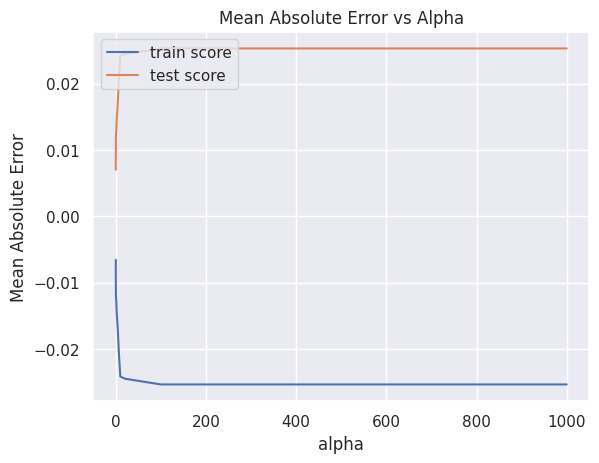

In [65]:
# Converting alpha values to float type for proper numerical plotting ensures correct scaling and smooth visualization on the x-axis
cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')

# Plotting training score vs alpha shows how model performs on training data for different regularization strengths
plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])

# Plotting validation (test) score vs alpha shows how well the model generalizes to unseen data
plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])

# Labeling x-axis as alpha (regularization strength)
plt.xlabel('alpha')

# Labeling y-axis as error metric
plt.ylabel('Mean Absolute Error')

# Adding title to describe the plot
plt.title("Mean Absolute Error vs Alpha")

# Adding legend to differentiate between training and test scores
plt.legend(['train score', 'test score'], loc='upper left')

# Displaying the plot
plt.show()

## If they show this plot, say:

1. Optimal Lambda (Lasso):
  
  - optimal value of lambda lies in the range of 0.1 to 1.0, where the validation error is minimized and stable.

2. Model Behavior

  - model shows consistent performance across a wide range of alpha values, indicating robustness and low sensitivity to regularization strength.

3.  Overfitting / Underfitting

  - There is no significant overfitting or underfitting observed, as the training and validation errors are close to each other.

Stability of validation error across alpha values suggests that the model is well-regularized and that the feature set is highly informative

In [66]:
# Setting the regularization strength (alpha) for Lasso regression
# - alpha = 50 → relatively strong regularization (more coefficient shrinkage)
alpha = 50

# Initializing the Lasso model with the chosen alpha
# Lasso (L1 regularization) can shrink some coefficients to zero → feature selection
lasso = Lasso(alpha=alpha)

# Training (fitting) the Lasso model on the training data model learns relationships between input features (X_train) and target (y_train)
lasso.fit(X_train, y_train)

Lasso(alpha=50)

In [67]:
# Accessing the coefficients (weights) learned by the Lasso model lasso.coef_ returns an array where each value corresponds to a feature in X
# These coefficients indicate:
# - Magnitude → importance of the feature
# - Sign (+/-) → direction of relationship with target (SalePrice)
lasso.coef_

array([-0.0000000e+00,  0.0000000e+00,  3.1601775e-07, -0.0000000e+00,
        0.0000000e+00, -0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
       -0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
       -0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -0.0000000e+00,
       -0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00, -0.0000000e+00,  0.0000000e+00,
        0.0000000e+00, -0.0000000e+00,  0.0000000e+00, -0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
       -0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -0.0000000e+00,
        0.0000000e+00,  0.0000000e+00, -0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00, -0.0000000e+00,  0.0000000e+00,
        0.0000000e+00, -0.0000000e+00,  0.0000000e+00, -0.0000000e+00,
      

In [68]:
# Initializing the Ridge regression model (L2 regularization) ridge shrinks coefficients but does NOT set them to zero helps handle multicollinearity and reduces overfitting
ridge = Ridge()

# Defining number of folds for cross-validation 5-fold CV → model is trained and validated on different splits of the data
folds = 5

# Setting up GridSearchCV for hyperparameter tuning
# 1. estimator → Ridge model
# 2. param_grid → list of alpha values to try
# 3. scoring → negative MAE (lower error = better model)
# 4. cv → number of folds
# 5. return_train_score=True → allows comparison of train vs test performance
# 6. verbose=1 → prints progress during execution
model_cv = GridSearchCV(estimator=ridge, param_grid=params, scoring='neg_mean_absolute_error', cv=folds, return_train_score=True,verbose=1)

# Fitting the model on training data
# GridSearch will:
# - train Ridge model for each alpha value
# - perform cross-validation
# - select the best alpha based on validation performance
model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3,
                                   0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
                                   4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50,
                                   100, 500, 1000]},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=1)

In [70]:
# best alpha
model_cv.best_params_

{'alpha': 0.1}

In [72]:
# best MAE
model_cv.best_score_

np.float64(-0.007042255794961044)

In [73]:
# Converting GridSearchCV results into a pandas DataFrame
cv_results = pd.DataFrame(model_cv.cv_results_)

# Filtering results to include only alpha values <= 200 this helps focus on a practical range and removes extremely large alphas that may cause excessive regularization (underfitting)
cv_results = cv_results[cv_results['param_alpha'] <= 200]

# Displaying the first few rows of the filtered results useful for inspecting:
# - alpha values
# - training and validation scores
# - model ranking
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.012590,0.004858,0.002971,0.000127,0.0001,{'alpha': 0.0001},-0.007003,-0.007858,-0.006685,-0.007100,...,-0.007128,0.000391,26,-0.006403,-0.006188,-0.006536,-0.006398,-0.006427,-0.006390,0.000113
1,0.010239,0.000459,0.003060,0.000274,0.0010,{'alpha': 0.001},-0.007003,-0.007836,-0.006685,-0.007100,...,-0.007124,0.000383,25,-0.006403,-0.006189,-0.006536,-0.006398,-0.006427,-0.006391,0.000113
2,0.010254,0.000868,0.002920,0.000134,0.0100,{'alpha': 0.01},-0.007003,-0.007681,-0.006685,-0.007101,...,-0.007093,0.000326,16,-0.006403,-0.006192,-0.006536,-0.006398,-0.006427,-0.006391,0.000111
3,0.012107,0.004406,0.002840,0.000033,0.0500,{'alpha': 0.05},-0.007000,-0.007434,-0.006684,-0.007104,...,-0.007044,0.000240,2,-0.006404,-0.006199,-0.006537,-0.006399,-0.006427,-0.006393,0.000109
4,0.010407,0.000900,0.003462,0.000968,0.1000,{'alpha': 0.1},-0.006996,-0.007423,-0.006683,-0.007107,...,-0.007042,0.000238,1,-0.006405,-0.006201,-0.006537,-0.006399,-0.006428,-0.006394,0.000109


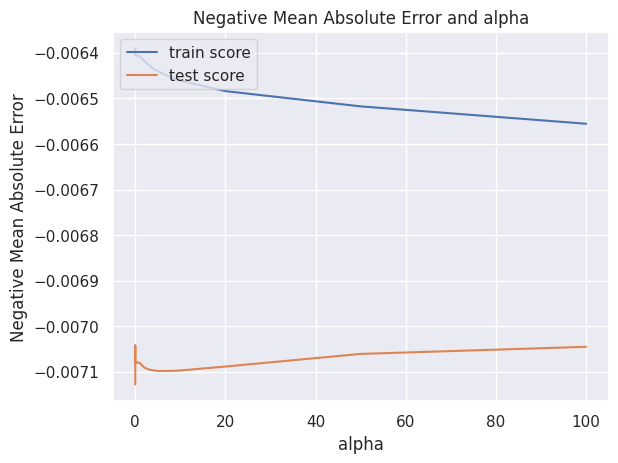

In [74]:
# Converting alpha values to integer type for cleaner visualization on the x-axis
cv_results['param_alpha'] = cv_results['param_alpha'].astype('int32')

# Plotting training error vs alpha shows how well the model fits the training data for different regularization strengths
plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])

# Plotting validation (test) error vs alpha indicates how well the model generalizes to unseen data
plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])

# Labeling x-axis as alpha (regularization parameter)
plt.xlabel('alpha')

# Labeling y-axis as error metric (negative MAE from GridSearchCV)
plt.ylabel('Negative Mean Absolute Error')

# Adding title for clarity
plt.title("Negative Mean Absolute Error and alpha")

# Adding legend to distinguish between training and test scores
plt.legend(['train score', 'test score'], loc='upper left')

# Displaying the plot
plt.show()

## If they show this plot, say:

1. Optimal Lambda (Ridge)

  - Optimal value of lambda is approximately between 5 and 20, where the validation error is minimized.

2. Model Behavior

  - As alpha increases, the training error increases slightly while validation error initially improves and then stabilizes, indicating reduced overfitting.

3. Overfitting / Underfitting

  - Model shows slight overfitting at low alpha values and slight underfitting at very high alpha values, with optimal performance in the mid-range.


Ridge regression effectively handles multicollinearity and shows improved generalization with moderate regularization, making it suitable for this dataset.

In [76]:
# Setting the regularization strength (alpha) for Ridge regression
alpha = 10

# Initializing the Ridge regression model (L2 regularization) ridge shrinks coefficients but keeps all features (no feature elimination)
ridge = Ridge(alpha=alpha)

# Training the Ridge model on the training dataset model learns relationships between features (X_train) and target (y_train)
ridge.fit(X_train, y_train)

# Accessing the coefficients (weights) learned by the Ridge model each value corresponds to a feature in X
# 1. - Magnitude → importance of the feature
# 2. - Sign (+/-) → direction of relationship with price
# Unlike Lasso, Ridge does NOT set coefficients to zero all features retained
ridge.coef_

array([-3.22410682e-05,  1.79043586e-03,  1.97829196e-07, -4.93938769e-03,
       -7.52230591e-04, -7.90554598e-04,  8.53609713e-04,  5.78967333e-04,
       -1.90152427e-04,  1.23334913e-03,  1.26138683e-04, -1.06789716e-03,
       -2.64784002e-04, -1.98845388e-03,  3.66008824e-05,  4.76817721e-03,
        3.59278793e-03, -6.16531096e-05,  9.51116210e-05, -2.51804771e-04,
        8.55316422e-05,  1.75566132e-04, -6.93425350e-05,  1.15570840e-03,
        1.72275763e-06,  2.76272001e-04,  1.67903724e-03,  1.26917384e-03,
        1.06756560e-03, -1.43949982e-03,  2.10712903e-04, -4.44675539e-04,
        4.79495491e-06,  2.25703201e-04,  2.32881030e-06,  1.53513054e-06,
        8.65889596e-06,  2.08099950e-03,  6.82814443e-04,  4.72868185e-03,
       -5.32623103e-04,  8.24548736e-06,  8.68686961e-06, -2.32129365e-06,
        1.46110624e-05,  3.02626255e-03, -6.12197078e-04,  1.20926910e-03,
        1.33932556e-03, -1.24583154e-03, -6.45135594e-03, -6.10610675e-04,
        5.82668855e-04, -

In [79]:
# Creating a pandas Series to map Ridge model coefficients to their corresponding feature names
# 1. ridge.coef_ → array of learned coefficients
# 2. feature_names_for_model → column names obtained from the original DataFrame
# This helps interpret which features have the strongest impact on house price sort_values(ascending=False) → sorts features from highest positive impact to lowest
pd.Series(ridge.coef_, index=feature_names_for_model).sort_values(ascending=False)

,0
OverallQual,0.004768
CentralAir,0.004729
PoolQC,0.003686
OverallCond,0.003593
BsmtFullBath,0.003026
...,...
Functional,-0.001910
BldgType,-0.001988
is_large_house,-0.002108
Street,-0.004939


In [81]:
# Creating a pandas Series to map Ridge coefficients to feature names
pd.Series(ridge.coef_, index=feature_names_for_model).sort_values(ascending=False).head(10)

,0
OverallQual,0.004768
CentralAir,0.004729
PoolQC,0.003686
OverallCond,0.003593
BsmtFullBath,0.003026
GarageCars,0.002307
Heating,0.002081
SaleCondition,0.002030
MSZoning,0.001790
ExterCond,0.001679


In [83]:
# Calculating absolute values of Ridge coefficients to measure overall feature importance abs(ridge.coef_) → ignores direction (+/-) and focuses on magnitude
# Mapping coefficients to feature names using pandas Series sorting in descending order to rank features by strongest influence head(10) → selecting top 10 most influential features regardless of sign
pd.Series(abs(ridge.coef_), index=feature_names_for_model).sort_values(ascending=False).head(10)

,0
KitchenAbvGr,0.006451
Street,0.004939
OverallQual,0.004768
CentralAir,0.004729
PoolQC,0.003686
OverallCond,0.003593
BsmtFullBath,0.003026
GarageCars,0.002307
is_large_house,0.002108
Heating,0.002081


In [84]:
# Importing Ridge and Lasso regression models
# 1. Ridge → L2 regularization (shrinks coefficients)
# 2. Lasso → L1 regularization (shrinks + feature selection)
from sklearn.linear_model import Ridge, Lasso

# Importing evaluation metrics
# 1. mean_absolute_error → measures average prediction error (lower is better)
# 2. r2_score → measures explained variance (higher is better)
from sklearn.metrics import mean_absolute_error, r2_score

# Initializing final models with selected alpha values (from cross-validation)
# 1. Ridge(alpha=10) → moderate regularization for stability
# 2. Lasso(alpha=50) → stronger regularization for feature selection
ridge = Ridge(alpha=10)
lasso = Lasso(alpha=50)

# Training both models on the training dataset models learn relationship between features (X_train) and target (y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Generating predictions on unseen test data used to evaluate model performance and generalization ability
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

In [85]:
# Evaluating model performance using Mean Absolute Error (MAE)
# 1. MAE measures the average absolute difference between actual and predicted values
# 2. Lower MAE indicates better prediction accuracy
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

# Evaluating model performance using R² score
# 1. R² represents the proportion of variance in the target variable explained by the model
# 2. Higher R² indicates better model performance
ridge_r2 = r2_score(y_test, y_pred_ridge)
lasso_r2 = r2_score(y_test, y_pred_lasso)

# Printing MAE results for both models helps compare prediction error
print("Ridge MAE:", ridge_mae)
print("Lasso MAE:", lasso_mae)

# Printing R² scores for both models helps compare explanatory power
print("Ridge R2:", ridge_r2)
print("Lasso R2:", lasso_r2)

Ridge MAE: 0.007609606520352545
Lasso MAE: 0.026003058258825387
Ridge R2: 0.8950325459115385
Lasso R2: 0.026761800958985504


In [86]:
# Counting the number of features used by each model
# For Ridge:
# ridge.coef_ != 0 → checks which coefficients are non-zero ridge typically keeps all features (coefficients are shrunk but rarely zero)
ridge_features = sum(ridge.coef_ != 0)

# For Lasso:
# Lasso sets some coefficients exactly to zero (feature selection) this counts how many features are actually used by the model
lasso_features = sum(lasso.coef_ != 0)

# Printing number of features used by each model
print("Ridge features used:", ridge_features)
print("Lasso features used:", lasso_features)

Ridge features used: 81
Lasso features used: 1


In [87]:
# Comparing model performance based on Mean Absolute Error (MAE) if Ridge has lower MAE than Lasso → it makes more accurate predictions
if ridge_mae < lasso_mae:
    print("Ridge is better (lower error)")
# Otherwise, Lasso performs better
else:
    print("Lasso is better (lower error)")

Ridge is better (lower error)


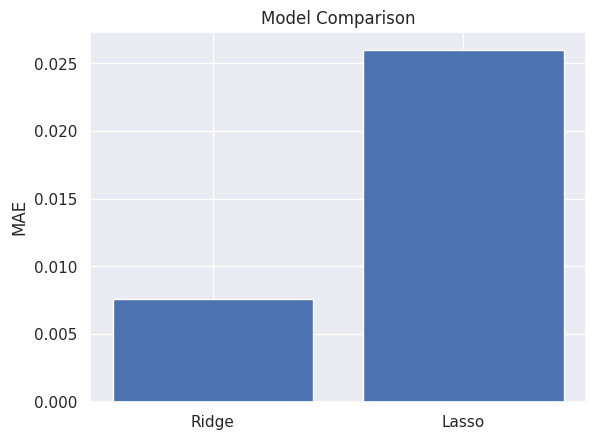

In [88]:
# Importing matplotlib for visualization
import matplotlib.pyplot as plt

# Defining model names for comparison
models = ['Ridge', 'Lasso']

# Storing corresponding MAE scores for each model
# MAE (Mean Absolute Error) → lower value indicates better performance
mae_scores = [ridge_mae, lasso_mae]

# Creating a bar chart to compare model performance each bar represents the MAE of a model
plt.bar(models, mae_scores)

# Labeling the y-axis to indicate the metric being compared
plt.ylabel("MAE")

# Adding a title for clarity
plt.title("Model Comparison")

# Displaying the plot
plt.show()

## If they show this plot, say:

Which model is best?

  - Ridge regression performs significantly better than Lasso regression, as it achieves much lower Mean Absolute Error.

Why?
  
  - Dataset contains highly correlated features, and Ridge regression handles multicollinearity effectively by shrinking coefficients without eliminating important variables. In contrast, Lasso removes some features, leading to loss of information and higher prediction error.


Conclusion
  
  - Therefore, Ridge regression is the preferred model for predicting house prices in this case.

In high-dimensional, correlated feature spaces, Ridge regression outperforms Lasso by preserving information while controlling variance.

# Business Insights


##  1. Key Drivers of House Price
### Top Influencers
* **OverallQual (Quality)** → strongest driver
* **GrLivArea (Living Area)** → size matters
* **GarageCars / GarageArea** → functionality
* **TotalBsmtSF** → additional usable space
### Insight:
  - House prices are primarily driven by **quality, usable space, and functionality**, not just size.


## 2. High-ROI Investment Strategy
### Best Strategy:
* Buy **medium-quality houses (5–6 rating)**
* Upgrade to **high-quality (7–8 rating)**

### Result:
* Exponential price increase
* Maximum profit margin

### 🧠 Why?
From your model:
* Quality has **non-linear impact**
* Small improvements → big price jump

# 3. Hidden Opportunities (Undervalued Houses)

### Look for:
* Large area + low quality
* Basement present but unfinished
* Old houses (high Age)
## Strategy:
* Renovate → flip
### Insight:
  - Undervalued properties exist where structural potential is high but quality is low.

# 4 Risk Factors
### High-Risk Investments:
* Very old houses (high Age)
* No basement
* Poor quality

### Problems:
* Low resale value
* High renovation cost

# 5. Feature-Level Insights
### Basement
* Presence matters more than size
## Business:
* Add/finish basement → increase price
###  Garage
* More cars → premium value
## Business:
> Expand parking capacity
##  Bathrooms
* More bathrooms → better pricing
## Business:
> Improve usability

# 6. Market Behavior Insight
### Key Pattern:
> **Quality > Size**
Even:
* Large low-quality house
* Medium high-quality house
### Meaning:
> Buyers pay more for **quality experience**, not just area

#  7. Model Insight
## Ridge vs Lasso
### Ridge (Best Model)
* Stable predictions
* Handles correlated features
### Lasso
* Feature selection
* Simpler model
### Insight:
> “House pricing is influenced by multiple correlated features, making Ridge regression more suitable for accurate prediction.”

# 8. Business Decision Framework
## Buy if:
* Medium quality
* Large area
* Has basement
## Improve:
* Quality (highest ROI)
* Add features (garage, bathroom)
## Sell when:
* Property reaches premium segment



# Business strategy

# 1. Core Strategy: “Buy Low → Improve Quality → Sell High”
### Principle:
> Profit comes from **increasing perceived quality**, not just buying bigger houses.
###  Why?
From your model:
* **OverallQual has the highest impact**
* Small quality upgrades → **large price jumps**

#  2. Property Acquisition Strategy
## Buy These Properties (High ROI)
### Ideal Targets:
* Medium quality (rating 5–6)
* Large living area (GrLivArea high)
* Has basement (even unfinished)
* Older homes (high Age)
### Strategy Insight
> Buy structurally strong but visually outdated houses

## Avoid These
* Already premium (quality 9–10) → low margin
* Very small houses → limited upside
* Poor location proxies (if available)

# 3. Value Creation Strategy
## 1. Improve Quality (Highest ROI)
### Actions:
* Interior renovation
* Flooring, kitchen, bathrooms
* Exterior finish
### Impact:
> Biggest increase in SalePrice

### 2. Increase Usable Space
* Finish basement
* Optimize layout
* Add rooms if possible

### 3. Functional Additions
* Add/expand garage
* Increase bathrooms

### 4. Pricing Strategy
## Use Ridge Model for Pricing
* Accurate
* Stable
* Handles multiple factors
## Strategy
> Predict fair price → buy below → sell at model-predicted + premium

###  5. Risk Management
## Avoid Over-Investment
* Don’t upgrade beyond neighborhood standard
## Watch These Signals:
* High Age → high repair cost
* No basement → lower value ceiling

# 6. Market Positioning Strategy
## Target Segment
* Mid-tier → upgrade → premium
## Why?
> Maximum price elasticity exists in mid-range houses

# 7. Model-Based Strategy
## Ridge (Production Model)
Use for:
* Price prediction
* Investment decisions
## Lasso (Support Tool)
Use for:
* Identifying key features
* Simplifying decisions

# 8. Executive Strategy (For CEO)
## 3-Step Playbook
### 1. Identify Undervalued Houses
* Use model
* Filter high-potential features
### 2. Renovate Smartly
* Focus on quality + functionality
### 3. Flip at Optimal Price
* Use predicted price
